In [3]:
!pip install brian2

     |████████████████████████████████| 1.6MB 2.8MB/s 
     |████████████████████████████████| 5.6MB 20.4MB/s 
  Created wheel for brian2: filename=Brian2-2.3.0.2-cp36-cp36m-linux_x86_64.whl size=1283458 sha256=35c483c8fe5b9f0693514ae25049d5b5b4278db5322b410c10cf1d4df3d31cac
  Stored in directory: /root/.cache/pip/wheels/86/b5/f6/0c8f9eec58c01e4af55a4c79a5e0385aea01ed03e4ec36c4ac
Successfully built brian2
  Found existing installation: sympy 1.1.1
    Uninstalling sympy-1.1.1:
      Successfully uninstalled sympy-1.1.1


In [0]:
from brian2 import *
import time
from scipy import optimize
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from sympy.solvers import solve
from sympy import symbols
import sympy as sp
%matplotlib inline

cl=Clock(dt=0.1*ms)

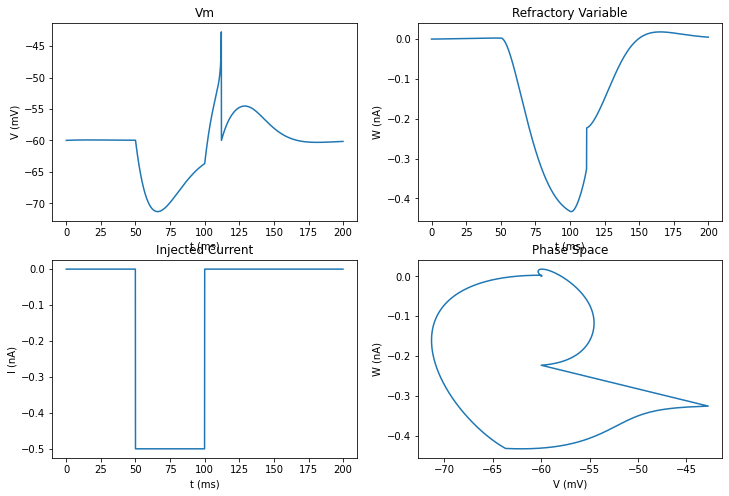

[5.] Hz


In [5]:
start_scope()

eqs='''
dvm/dt = (gL*(EL-vm)+gL*DeltaT*exp((vm-VT)/DeltaT)+I_input-w)/C : volt
dw/dt = (a*(vm-EL)-w)/tauw : amp
I_input : amp
'''

# Here you can select which different kinds of neuronal responses to run. 
name='rebound_spike'

# general parameters:
C=281*pF # Can be fixed
gL=30*nS
taum=C/gL
EL=-70.6*mV # Same as changing I
VT=-50.4*mV
DeltaT=2*mV
Vcut=VT+5*DeltaT

# stimulation parameters:
I0=0*nA
I2 = 0*nA
dv0=0*mV # voltage transient
T0=50*ms
T1=300*ms
T2=100*ms

# selected type:

if name=='phasic':
    tauw=150*ms
    a=2*C/tauw # type II
    b=0*nA
    Vr=-70.6*mV
    #I=0*nA
    EL=-60*mV
    I_john=(1+a/gL)*log(1+taum/tauw)-(1+taum/tauw)
    I0=gL*DeltaT*I_john+(VT-EL)*(gL+a)-0.03*nA
    I=I0
    T0=100*ms
    T1=200*ms
    T2=20*ms
    dv0=2.5*mV
elif name=='rebound_spike':
    tauw=150*ms
    #T0=
    a=200*nS
    b=0.1*nA
    I0=0*nA
    I=-0.5*nA
    EL=-60*mV
    T1=50*ms
    VT=-54*mV
    Vr=EL
elif name=='rebound_burst':
    tauw=150*ms
    #T0=
    a=200*nS
    b=0.1*nA
    I0=0*nA
    I=-0.5*nA
    EL=-60*mV
    T1=50*ms
    VT=-54*mV
    Vr=VT+3*mV
elif name=='regular':
    tauw=144*ms
    a=4*nS
    b=0.0805*nA
    Vr=-70.6*mV
    I=1*nA
elif name=='phasic':
    tauw=144*ms
    a=4*nS
    b=0.0805*nA
    Vr=-70.6*mV
    I=.6*nA
elif name=='on_off':
    tauw=10*ms
    a=800*nS
    b=10*nA
    Vr=-70.6*mV
    I=11*nA
elif name=='oscillator??': # numerical integration problem
    tauw=14*ms
    a=8000*nS
    b=0.0805*nA
    Vr=-70.6*mV
    I=1.3*nA
elif name=='mixed':
    tauw=144*ms
    a=4*nS
    b=0.15*nA
    Vr=VT+2*mV
    I=1*nA
elif name=='fast':
    # Type II: a > C/tauw
    tauw=144*ms
    a=2*C/tauw
    b=0*nA
    Vr=-70.6*mV
    I_john=(1+a/gL)*log(1+taum/tauw)-(1+taum/tauw)
    I=gL*DeltaT*I_john+(VT-EL)*(gL+a)+0.01*nA
    I0=I-0.1*nA
    T0=200*ms
elif name=='bursting_tonic':
    tauw=20*ms
    a=4*nS
    b=0.5*nA
    Vr=VT+5*mV
    I=.8*nA
elif name=='bursting_phasic':
    tauw=144*ms
    a=4*nS
    b=0.1*nA
    Vr=VT+4*mV
    I=.6*nA
elif name=='bursting_phasic2': # big burst, then small bursts
    tauw=144*ms
    a=4*nS
    b=0.15*nA
    Vr=VT+2*mV
    I=1.5*nA

N=1 # number of neurons
neuron=NeuronGroup(N,model=eqs,threshold='vm>Vcut', reset="vm = Vr; w += b", method='euler')

neuron.w = 0*amp;
neuron.vm = EL;

mon_v=StateMonitor(neuron,'vm',record=0) 
# to retrieve the values of vm of the first neuron, write 'mon_v.vm[0] or mon_v.vm

mon_I=StateMonitor(neuron,'I_input',record=0)
mon_w=StateMonitor(neuron,'w',record=0)
spikes=SpikeMonitor(neuron) # the spike monitor records the times of the spikes in the array 'spikes.t'

# run a bit without input
neuron.I_input=I0
run(T0)

# then add a current clamp and run a for another bit
neuron.I_input=I
run(T1)

#then go back to a resting state
neuron.I_input=0*nA
run(T2)

figure(figsize=(12,8))
subplot(221)
plot(mon_v.t/ms,mon_v.vm[0]/mV)
ylabel('V (mV)')
xlabel('t (ms)')
title('Vm')

# w
subplot(222)
plot(mon_w.t/ms,mon_w.w[0]/nA)
ylabel('W (nA)')
xlabel('t (ms)')
title('Refractory Variable')

# I
subplot(223)
plot(mon_I.t/ms,mon_I.I_input[0]/nA)
ylabel('I (nA)')
xlabel('t (ms)')
title('Injected Current')

# Phase plot
subplot(224)
plot(mon_v.vm[0]/mV,mon_w.w[0]/nA)
ylabel('W (nA)')
xlabel('V (mV)')
title('Phase Space')

show()
print(spikes.count/(T1+T2+T0))

# Nullcline and streamline plots

## Find the nullcline equations

In [0]:
# here we use pythons 'symbolic computation' capabilities

# define variables
vm1,w1,C1,gL1,taum1,EL1,VT1,DeltaT1,Vcut1,tauw1,a1,b1,I_input1 = symbols('vm w C gL taum EL VT DeltaT Vcut tauw a b I_input')

# solve the vm nullcline (isolate w1 to the left side of the equation)
vm_eq = solve((gL1*(EL1-vm1)+gL1*DeltaT1*sp.exp((vm1-VT1)/DeltaT1)+I_input1-w1)/C1,w1)

# solve the w nullcline for w1
w_eq = solve((a1*(vm1-EL1)-w1)/tauw1,w1)

y_vm = vm_eq[0]
y_w = w_eq[0]

### Equations 
print('\n Symbolic:\n','\nVm Nullcline:\n', " w = ", y_vm,'\nW Nullcline:\n', " w = ", y_w)

def nl(gL,EL,VT,DeltaT,a,I):
    yvm = y_vm.subs(gL1,gL/nsiemens)
    yvm = yvm.subs(EL1,EL/mvolt)
    yvm = yvm.subs(VT1,VT/mvolt)
    yvm = yvm.subs(DeltaT1,DeltaT/mvolt)
    yvm = yvm.subs(I_input1, I/namp)
    yw = y_w.subs(a1,a/nsiemens)
    yw = yw.subs(EL1,EL/mvolt)
    return [yvm, yw]
  
  
eqs_nl = nl(gL,EL,VT,DeltaT,a,I)
vm_0 = eqs_nl[0]
w_0 = eqs_nl[1]

### Instantiating Constants in the Equations for plotting
print('\n Simplified:\n','\nVm Nullcline:\n', " w = ", vm_0,'\nW Nullcline:\n', " w = ", w_0)


 Symbolic:
 
Vm Nullcline:
  w =  DeltaT*gL*exp((-VT + vm)/DeltaT) + EL*gL + I_input - gL*vm 
W Nullcline:
  w =  a*(-EL + vm)

 Simplified:
 
Vm Nullcline:
  w =  -30.0*vm + 31922894436107.9*exp(0.5*vm) - 1800.5 
W Nullcline:
  w =  200.0*vm + 12000.0


## Find the Equilibria

### Write the equations of the nullclines from your results

In [0]:
### Choose range for vm and w  
vm = np.linspace(-100.0, 20.0, 120000)
# w = np.linspace(-600.0, 5000.0, 6500000)


print('\nVm Nullcline:\n', " w = ", vm_0)
print('\nW Nullcline:\n', " w = ", w_0)


Vm Nullcline:
  w =  -30.0*vm + 31922894436107.9*exp(0.5*vm) - 1800.5

W Nullcline:
  w =  200.0*vm + 12000.0


In [0]:
### Manual step: copy and paste the above equations here!
y1 = -30.0*vm + 31922894436107.9*exp(0.5*vm) - 1800.5
y2 = 200.0*vm + 12000.0

### Find Intersections

In [0]:
idx=np.argwhere(np.diff(np.sign(y1 - y2 )) != 0).reshape(-1) + 0

intersec = np.zeros((len(idx),2))
for i in range(len(idx)):
    x_pos = (vm[idx[i]]+vm[idx[i]+1])/2.
    y_pos = (y1[idx[i]]+y1[idx[i]+1])/2.
    intersec[i] = x_pos,y_pos

### Plot intersections

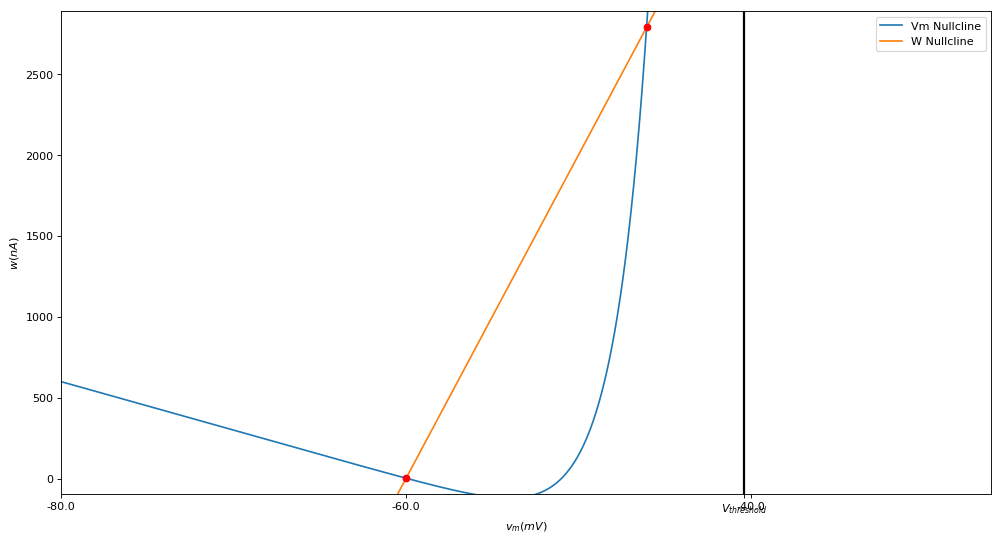

In [0]:
fig, ax = plt.subplots(figsize=(15, 8), dpi= 80, facecolor='w', edgecolor='k')
ax.vlines(Vcut/mV, (intersec[1][0]-100), (intersec[1][-1]+100), lw=2, color='k')
plt.plot(vm,y1, label="Vm Nullcline")
plt.plot(vm,y2, label="W Nullcline")
for i in range(len(idx)):
    plt.plot(intersec[i][0],intersec[i][1], 'ro')
xt = ax.get_xticks() 
xt=np.append(xt,Vcut/mV)
xtl=xt.tolist()
xtl[-1]="$V_{threshold}$"
ax.set_xticks(xt)
ax.set_xticklabels(xtl)
xlabel('$v_m (mV)$')
ylabel('$w (nA)$')
plt.xlim([(intersec[0][0]-20), (intersec[1][0]+20)])
plt.ylim([(intersec[0][1]-200), (intersec[1][-1]+200)])
legend();
plt.show() 

## Verify your nullclines

In [0]:
### Equation
fvm = vm_0-w1
fw = w_0-w1

### Intersection point 1
f1 = fvm.subs(vm1,intersec[0][0])
f1 = f1.subs(w1,intersec[0][1])
print('\ndvm/dt = \n',round(f1,1))

### Intersection point 2
f2 = fw.subs(vm1,intersec[0][0])
f2 = f2.subs(w1,intersec[0][1])
print('\ndw/dt = \n',round(f2,1))


dvm/dt = 
 -0.0

dw/dt = 
 -0.0


## Define the ODEs to plot the streamlines

In [0]:
def f(Y, t, C,gL,taum,EL,VT,DeltaT,Vcut,tauw,a,b,I):
    C=C/pfarad # Can be fixed
    gL=gL/nsiemens
    taum=taum/msecond
    EL=EL/mvolt # Same as changing I
    VT=VT/mvolt
    DeltaT=DeltaT/mvolt
    Vcut=Vcut/mvolt
    I_input = I/nA
    tauw = tauw/msecond
    a = a/nsiemens
    b = b/nA
    vm, w = Y
    return [(gL*(EL-vm)+gL*DeltaT*exp((vm-VT)/DeltaT)+I_input-w)/C, (a*(vm-EL)-w)/tauw]

  
### Choose range for vm and w   
vm_stream = np.linspace((intersec[0][0]-20), (intersec[1][0]+20), (2*(intersec[1][0]-intersec[0][0])))
w_stream = np.linspace((intersec[0][1]-500), (intersec[1][1]+200), (2*(intersec[1][1]-intersec[0][1])))


### Colve the ODE
Y1, Y2 = np.meshgrid(vm_stream, w_stream)
t = 0
u, v = np.zeros(Y1.shape), np.zeros(Y2.shape)
NI, NJ = Y1.shape
for i in range(NI):
    for j in range(NJ):
        x = Y1[i, j]
        y = Y2[i, j]
        yprime = f([x, y], t, C,gL,taum,EL,VT,DeltaT,Vcut,tauw,a,b,I)
        u[i,j] = yprime[0]
        v[i,j] = yprime[1]


print('\nVm Nullcline:\n', " w = ", vm_0)
print('\nW Nullcline:\n', " w = ", w_0)

WARNING    /usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:18: DeprecationWarning: object of type <class 'numpy.float64'> cannot be safely interpreted as an integer.
 [py.warnings]
WARNING    /usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:19: DeprecationWarning: object of type <class 'numpy.float64'> cannot be safely interpreted as an integer.
 [py.warnings]



Vm Nullcline:
  w =  -30.0*vm + 31922894436107.9*exp(0.5*vm) - 1800.5

W Nullcline:
  w =  200.0*vm + 12000.0


## Plot nullclines with streamlines

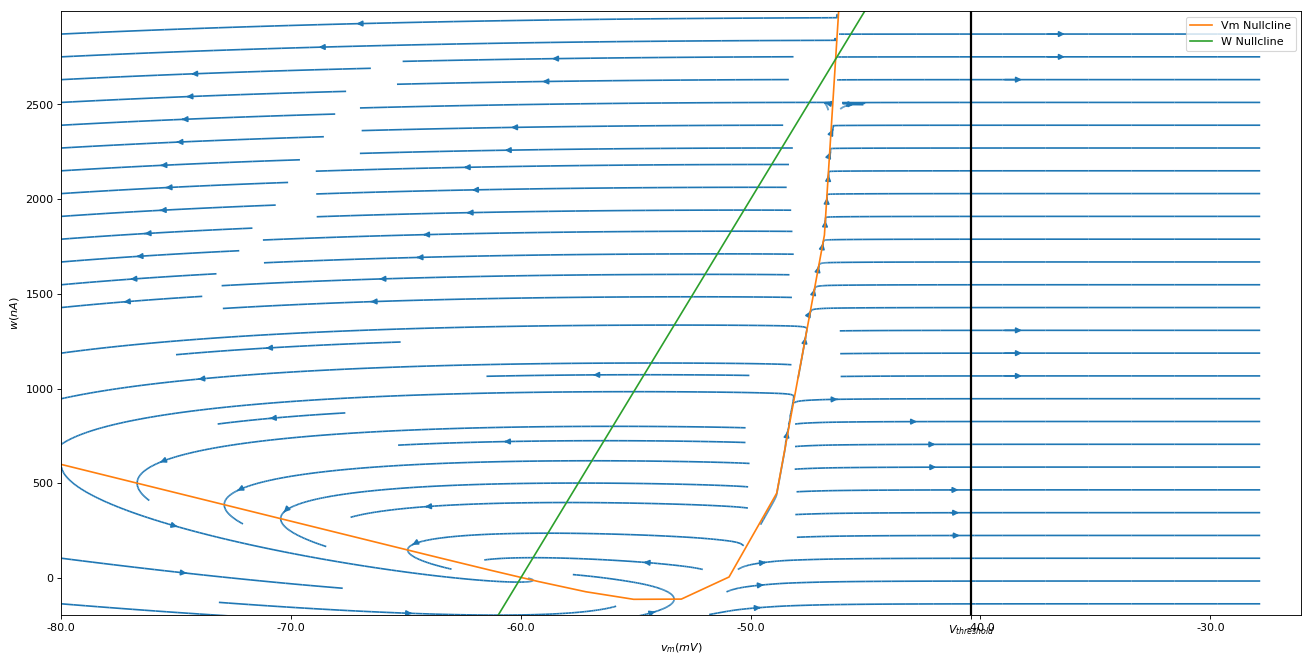

In [0]:
### Copy paste the equations here! (Use vm_stream)
y1_stream = -30.0*vm_stream + 31922894436107.9*exp(0.5*vm_stream) - 1800.5
y2_stream = 200.0*vm_stream + 12000.0

fig, ax = plt.subplots(figsize=(20, 10), dpi= 80, facecolor='w', edgecolor='k')
Q = ax.streamplot(Y1, Y2, u, v)
ax.vlines(Vcut/mV, (intersec[1][0]-200), (intersec[1][-1]+200), lw=2, color='k')
plt.plot(vm_stream,y1_stream, label="Vm Nullcline")
plt.plot(vm_stream,y2_stream, label="W Nullcline")
xt = ax.get_xticks() 
xt=np.append(xt,Vcut/mV)
xtl=xt.tolist()
xtl[-1]="$V_{threshold}$"
ax.set_xticks(xt)
ax.set_xticklabels(xtl)
xlabel('$v_m (mV)$')
ylabel('$w (nA)$')
plt.xlim([(intersec[0][0]-20), (intersec[1][0]+20)])
plt.ylim([(intersec[0][1]-200), (intersec[1][-1]+200)])
legend();
plt.show()

## Plot nullclines, streamlines and orbit of spiking neuron

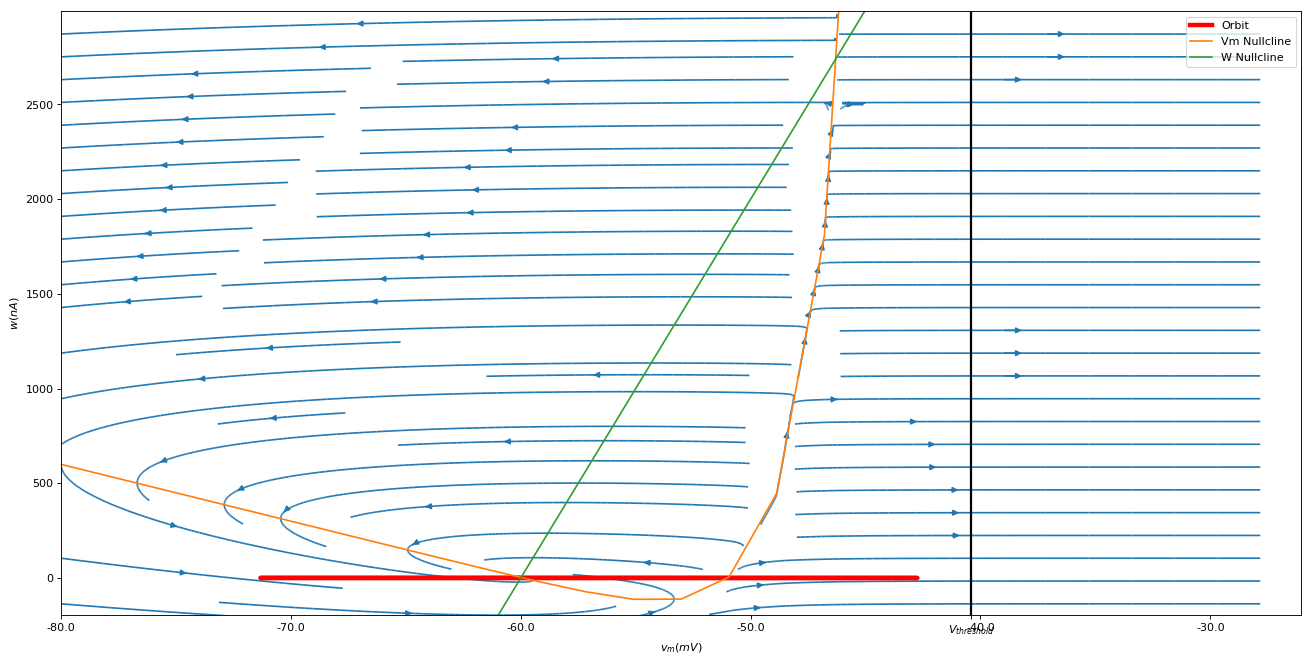

In [0]:
vm_orbit = mon_v.vm[0]/mV
w_orbit = mon_w.w[0]/nA

fig, ax = plt.subplots(figsize=(20, 10), dpi= 80, facecolor='w', edgecolor='k')
Q = ax.streamplot(Y1, Y2, u, v)
ax.vlines(Vcut/mV, (intersec[1][0]-200), (intersec[1][-1]+200), lw=2, color='k')
plt.plot(vm_orbit,w_orbit, label="Orbit", lw=4, color='r')
plt.plot(vm_stream,y1_stream, label="Vm Nullcline")
plt.plot(vm_stream,y2_stream, label="W Nullcline")
xt = ax.get_xticks() 
xt=np.append(xt,Vcut/mV)
xtl=xt.tolist()
xtl[-1]="$V_{threshold}$"
ax.set_xticks(xt)
ax.set_xticklabels(xtl)
xlabel('$v_m (mV)$')
ylabel('$w (nA)$')
plt.xlim([(intersec[0][0]-20), (intersec[1][0]+20)])
plt.ylim([(intersec[0][1]-200), (intersec[1][-1]+200)])
legend();
plt.show()

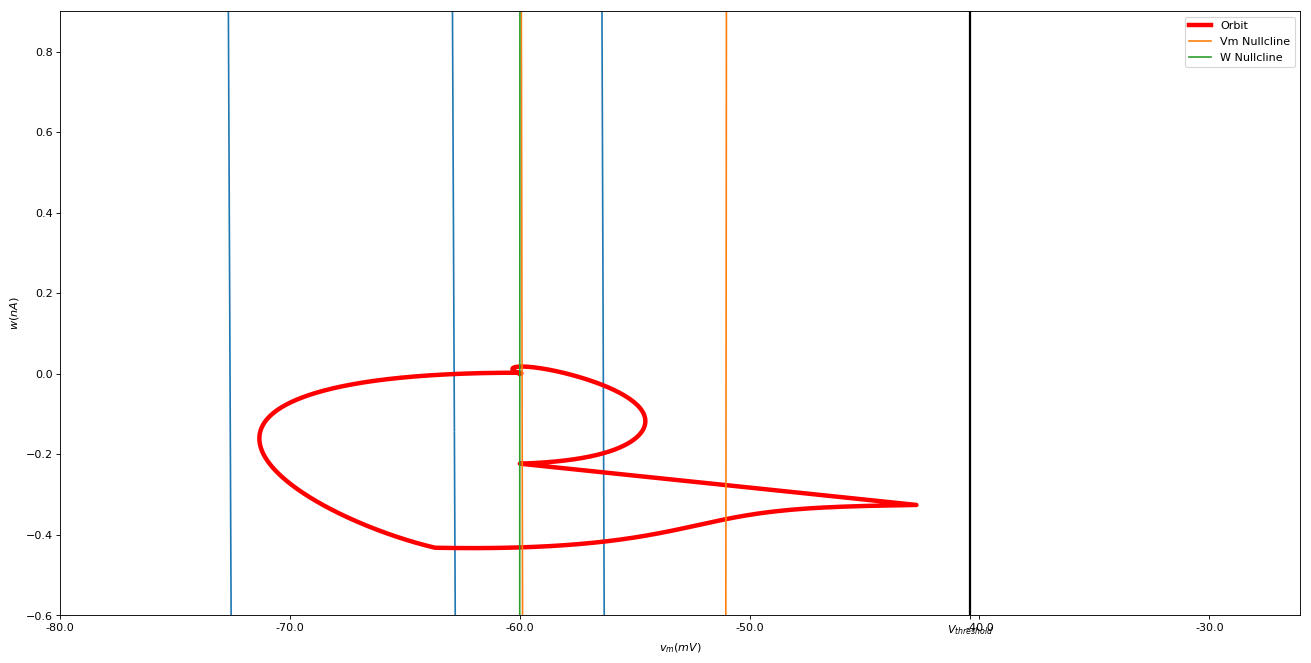

In [0]:
fig, ax = plt.subplots(figsize=(20, 10), dpi= 80, facecolor='w', edgecolor='k')
Q = ax.streamplot(Y1, Y2, u, v)
ax.vlines(Vcut/mV, (intersec[1][0]-200), (intersec[1][-1]+200), lw=2, color='k')
plt.plot(vm_orbit,w_orbit, label="Orbit", lw=4, color='r')
plt.plot(vm_stream,y1_stream, label="Vm Nullcline")
plt.plot(vm_stream,y2_stream, label="W Nullcline")
xt = ax.get_xticks() 
xt=np.append(xt,Vcut/mV)
xtl=xt.tolist()
xtl[-1]="$V_{threshold}$"
ax.set_xticks(xt)
ax.set_xticklabels(xtl)
xlabel('$v_m (mV)$')
ylabel('$w (nA)$')
plt.xlim([(intersec[0][0]-20), (intersec[1][0]+20)])
plt.ylim([(-0.6), (0.9)])
legend();
plt.show()

# Jacobian

Let's consider the function **f**. You may recognize the AdEx equations. 

\begin{align*}
\textbf{f}(v_m,w) =& 
\begin{bmatrix} 
\frac{1}{C} \left(\Delta_T\cdot g_L \cdot e^{\frac{1}{\Delta_T} \left(- V_T + vm\right)} + I_{input} + g_L \left(E_L - v_m\right) - w\right) \\ 
\frac{1}{tau_w} \left(a \left(- E_L + v_m\right) - w\right)
\end{bmatrix}\\
\end{align*}

Then we have 
\begin{align*}
f_1(v_m,w) =& \frac{1}{C} \left(\Delta_T\cdot g_L\cdot e^{\frac{1}{\Delta_T} \left(- V_T + v_m\right)} + I_{input} + g_L \left(E_L - v_m\right) - w\right)\\
\end{align*}

and
\begin{align*}
f_2(v_m,w) =& \frac{1}{tau_w} \left(a \left(- E_L + v_m\right) - w\right)\\
\end{align*}

The Jacobian matrix of **f** is:
\begin{align*}
\textbf{J}_{\textbf{f}}(v_m,w) =& \begin{bmatrix} 
\frac{\partial f_1}{\partial v_m} & \frac{\partial }{\partial w}\\
\frac{\partial f_2}{\partial v_m} & \frac{\partial f_2}{\partial w}
\end{bmatrix}
 = \begin{bmatrix} 
\frac{\partial \left(\frac{1}{C} \left(\Delta_T\cdot g_L \cdot e^{\frac{1}{\Delta_T} \left(- V_T + v_m\right)} + I_{input} + g_L \left(E_L - v_m\right) - w\right)\right)}{\partial v_m} & \frac{\partial \left(\frac{1}{C} \left(\Delta_T\cdot g_L \cdot e^{\frac{1}{\Delta_T} \left(- V_T + vm\right)} + I_{input} + g_L \left(E_L - v_m\right) - w\right)\right)}{\partial w}\\
\frac{\partial \left(\frac{1}{tau_w} \left(a \left(- E_L + v_m\right) - w\right)\right)}{\partial v_m} & \frac{\partial \left(\frac{1}{tau_w} \left(a \left(- E_L + v_m\right) - w\right)\right)}{\partial w}
\end{bmatrix}\\
\end{align*}

## Install Symengine

In [0]:
pip install symengine

## Function **f**

In [0]:
### Write equations in symbol format
fvm = vm_0 - w1
fw = w_0 - w1

### Find the function f
print('\n f(vm,w) = \n', np.matrix([fvm,fw]))
print('\n f1(vm,w) = \n', fvm)
print('\n f2(vm,w) = \n', fw)


 f(vm,w) = 
 [[-30.0*vm - w + 31922894436107.9*exp(0.5*vm) - 1800.5
  200.0*vm - w + 12000.0]]

 f1(vm,w) = 
 -30.0*vm - w + 31922894436107.9*exp(0.5*vm) - 1800.5

 f2(vm,w) = 
 200.0*vm - w + 12000.0


## Compute the Jacobian

In [0]:
def Jacobian(v_str, f_list):
    vars = sp.symbols(v_str)
    f = sp.sympify(f_list)
    J = sp.zeros(len(f),len(vars))
    for i, fi in enumerate(f):
        for j, s in enumerate(vars):
            J[i,j] = sp.diff(fi, s)
    return J

J = Jacobian('vm w', [fvm,fw])

print('\nJacobian Matrix:\n',J)


Jacobian Matrix:
 Matrix([[15961447218054.0*exp(0.5*vm) - 30.0, -1], [200.000000000000, -1]])


## Eigen value at each point

Take the 2x2 matrix of first derivatives at each fix point and compute its eigenvalues:  


*   Two negative eigenvalues at a fix point implies that the fix point is stable (trajectories starting from neighboring points converge to it).
*   Two positive eigenvalues indicates an unstable fix point (trajectories starting from neighboring points diverge from it).
*   One eigenvalue of each sign corresponds to a saddle point (trajectories from some neighboring points converge to it and others diverge).





In [0]:
## Point 1
J1 = J.subs(vm1,intersec[0][0])
JJ1 = np.array([[float(J1[0]),float(J1[1])],[float(J1[2]),float(J1[3])]])
e1 = np.linalg.eigvals(JJ1)

print('\nEigenvalues point 1:\n',e1)

## Point 2
J2 = J.subs(vm1,intersec[1][0])
JJ2 = np.array([[float(J2[0]),float(J2[1])],[float(J2[2]),float(J2[3])]])
e2 = np.linalg.eigvals(JJ2)

print('\nEigenvalues point 2:\n',e2)


Eigenvalues point 1:
 [-14.74913777+3.31077192j -14.74913777-3.31077192j]

Eigenvalues point 2:
 [ 1.57534375e+03 -8.73124120e-01]


### What type of fix points do we have?


*   For point 1:
*   For point 2:

